In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Kütüphaneler yüklendi ")


Kütüphaneler yüklendi 


In [65]:
df_overview  = pd.read_csv('../data/Overview.csv')
df_scores    = pd.read_csv('../data/Scores.csv')
df_corners   = pd.read_csv('../data/Corners.csv')
df_attack    = pd.read_csv('../data/attack.csv')
df_xg        = pd.read_csv('../data/xg.csv')

print(f"Overview:  {df_overview.shape}")
print(f"Scores:    {df_scores.shape}")
print(f"Corners:   {df_corners.shape}")
print(f"Attack:    {df_attack.shape}")
print(f"xG:        {df_xg.shape}")

Overview:  (189, 11)
Scores:    (189, 16)
Corners:   (189, 19)
Attack:    (189, 31)
xG:        (189, 13)


In [66]:
print("=== OVERVIEW İLK 3 SATIR ===")
print(df_overview.head(3))

print("\n=== KOLONLAR ===")
print(df_overview.columns.tolist())

=== OVERVIEW İLK 3 SATIR ===
       id       matchDate Country            League     Season       homeTeam  \
0  120952  30-05-26 18:00  Europe  Champions League  2025/2026            PSG   
1  119190  06-05-26 21:00  Europe  Champions League  2025/2026  Bayern Munich   
2  119184  05-05-26 21:00  Europe  Champions League  2025/2026        Arsenal   

      awayTeam                        referee  FTHG  FTAG FTR  
0      Arsenal                 Daniel Siebert     1     1   D  
1          PSG  Jonathan Benkenstein Pinheiro     1     1   D  
2  Atl. Madrid                 Daniel Siebert     1     0   H  

=== KOLONLAR ===
['id', 'matchDate', 'Country', 'League', 'Season', 'homeTeam', 'awayTeam', 'referee', 'FTHG', 'FTAG', 'FTR']


In [67]:
print("=== EKSİK VERİ KONTROLÜ ===")
print(df_overview.isnull().sum())
print(f"\nToplam maç sayısı: {len(df_overview)}")

=== EKSİK VERİ KONTROLÜ ===
id           0
matchDate    0
Country      0
League       0
Season       0
homeTeam     0
awayTeam     0
referee      0
FTHG         0
FTAG         0
FTR          0
dtype: int64

Toplam maç sayısı: 189


## Eksik Veri Analizi

Overview veri setinde hiçbir kolonda eksik değer bulunmamaktadır.
189 maçın tamamı eksiksiz kayıtlıdır. Bu durum Footiqo'nun veri
kalitesinin yüksek olduğunu göstermektedir.

In [68]:
print("=== TÜM VERİ SETLERİ EKSİK VERİ KONTROLÜ ===")
for isim, df in [("Overview", df_overview), 
                 ("Scores", df_scores),
                 ("Corners", df_corners),
                 ("Attack", df_attack),
                 ("xG", df_xg)]:
    eksik = df.isnull().sum().sum()
    print(f"{isim}: {eksik} eksik değer")

=== TÜM VERİ SETLERİ EKSİK VERİ KONTROLÜ ===
Overview: 0 eksik değer
Scores: 0 eksik değer
Corners: 0 eksik değer
Attack: 0 eksik değer
xG: 0 eksik değer


## Genel Eksik Veri Sonucu

5 veri setinin tamamında (Overview, Scores, Corners, Attack, xG)
hiçbir eksik değer bulunmamaktadır. Toplam 189 maça ait veriler
eksiksizdir. Bu nedenle eksik veri doldurma veya silme işlemi
uygulanmamıştır.

In [69]:
# id kolonu üzerinden tüm veri setlerini birleştir
df = df_overview.merge(df_scores, on='id', suffixes=('', '_scores'))
df = df.merge(df_corners, on='id', suffixes=('', '_corners'))
df = df.merge(df_attack, on='id', suffixes=('', '_attack'))
df = df.merge(df_xg, on='id', suffixes=('', '_xg'))

print(f"Birleştirilmiş veri seti: {df.shape}")
print(f"Kolonlar: {df.columns.tolist()}")

Birleştirilmiş veri seti: (189, 86)
Kolonlar: ['id', 'matchDate', 'Country', 'League', 'Season', 'homeTeam', 'awayTeam', 'referee', 'FTHG', 'FTAG', 'FTR', 'matchDate_scores', 'Country_scores', 'League_scores', 'Season_scores', 'homeTeam_scores', 'awayTeam_scores', 'FTHG_scores', 'FTAG_scores', 'FTR_scores', '1HHG', '1HAG', '1HR', '2HHG', '2HAG', '2HR', 'matchDate_corners', 'Country_corners', 'League_corners', 'Season_corners', 'homeTeam_corners', 'awayTeam_corners', 'HCFT', 'ACFT', 'HC1H', 'AC1H', 'HC2H', 'AC2H', 'HYCFT', 'AYCFT', 'HYC1H', 'AYC1H', 'HYC2H', 'AYC2H', 'matchDate_attack', 'Country_attack', 'League_attack', 'Season_attack', 'homeTeam_attack', 'awayTeam_attack', 'HBPFT', 'ABPFT', 'HBP1H', 'ABP1H', 'HBP2H', 'ABP2H', 'HTSFT', 'ATSFT', 'HTS1H', 'ATS1H', 'HTS2H', 'ATS2H', 'HSONFT', 'ASONFT', 'HSON1H', 'ASON1H', 'HSON2H', 'ASON2H', 'HSOFFFT', 'ASOFFFT', 'HSOFF1H', 'ASOFF1H', 'HSOFF2H', 'ASOFF2H', 'matchDate_xg', 'Country_xg', 'League_xg', 'Season_xg', 'homeTeam_xg', 'awayTeam_xg

In [70]:
# Tekrar eden gereksiz kolonları sil
gereksiz = [col for col in df.columns if col.endswith(('_scores', '_corners', '_attack', '_xg'))]
df = df.drop(columns=gereksiz)

print(f"Temizlenmiş veri seti: {df.shape}")
print(f"Kolonlar: {df.columns.tolist()}")

Temizlenmiş veri seti: (189, 59)
Kolonlar: ['id', 'matchDate', 'Country', 'League', 'Season', 'homeTeam', 'awayTeam', 'referee', 'FTHG', 'FTAG', 'FTR', '1HHG', '1HAG', '1HR', '2HHG', '2HAG', '2HR', 'HCFT', 'ACFT', 'HC1H', 'AC1H', 'HC2H', 'AC2H', 'HYCFT', 'AYCFT', 'HYC1H', 'AYC1H', 'HYC2H', 'AYC2H', 'HBPFT', 'ABPFT', 'HBP1H', 'ABP1H', 'HBP2H', 'ABP2H', 'HTSFT', 'ATSFT', 'HTS1H', 'ATS1H', 'HTS2H', 'ATS2H', 'HSONFT', 'ASONFT', 'HSON1H', 'ASON1H', 'HSON2H', 'ASON2H', 'HSOFFFT', 'ASOFFFT', 'HSOFF1H', 'ASOFF1H', 'HSOFF2H', 'ASOFF2H', 'homeXGFT', 'awayXGFT', 'homeXG1H', 'awayXG1H', 'homeXG2H', 'awayXG2H']


## Kolon Açıklamaları

**Maç Bilgisi:**
- FTHG / FTAG → Full Time Home/Away Goals (Maç sonu gol)
- FTR → Full Time Result (H=Ev kazandı, A=Deplasman kazandı, D=Beraberlik)
- 1HHG / 1HAG → 1. Yarı Ev/Deplasman Golü
- 2HHG / 2HAG → 2. Yarı Ev/Deplasman Golü

**Korner & Kart:**
- HCFT / ACFT → Ev/Deplasman Korner (Maç sonu)
- HYCFT / AYCFT → Ev/Deplasman Sarı Kart (Maç sonu)

**Şut İstatistikleri:**
- HTSFT / ATSFT → Ev/Deplasman Toplam Şut
- HSONFT / ASONFT → Ev/Deplasman İsabetli Şut
- HSOFFFT / ASOFFFT → Ev/Deplasman Isabetsiz Şut
- HBPFT / ABPFT → Ev/Deplasman Top Hakimiyeti (%)

**Beklenen Gol:**
- homeXGFT / awayXGFT → Ev/Deplasman xG (Maç sonu)

In [71]:
print("=== IQR AYKIRI DEĞER ANALİZİ ===\n")

kolonlar = ['FTHG', 'FTAG', 'HTSFT', 'ATSFT', 'HSONFT', 'ASONFT']

for col in kolonlar:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    alt = Q1 - 1.5 * IQR
    ust = Q3 + 1.5 * IQR
    aykiri = df[(df[col] < alt) | (df[col] > ust)]
    print(f"{col}: {len(aykiri)} aykırı değer (Alt: {alt:.1f}, Üst: {ust:.1f})")

=== IQR AYKIRI DEĞER ANALİZİ ===

FTHG: 1 aykırı değer (Alt: -2.0, Üst: 6.0)
FTAG: 3 aykırı değer (Alt: -3.0, Üst: 5.0)
HTSFT: 3 aykırı değer (Alt: -1.0, Üst: 31.0)
ATSFT: 3 aykırı değer (Alt: -2.5, Üst: 25.5)
HSONFT: 2 aykırı değer (Alt: -2.0, Üst: 14.0)
ASONFT: 5 aykırı değer (Alt: -4.0, Üst: 12.0)


In [72]:
from scipy import stats

print("=== Z-SCORE AYKIRI DEĞER ANALİZİ (|z| > 3) ===\n")

for col in kolonlar:
    z_scores = np.abs(stats.zscore(df[col]))
    aykiri = (z_scores > 3).sum()
    print(f"{col}: {aykiri} aykırı değer")

=== Z-SCORE AYKIRI DEĞER ANALİZİ (|z| > 3) ===

FTHG: 1 aykırı değer
FTAG: 3 aykırı değer
HTSFT: 1 aykırı değer
ATSFT: 2 aykırı değer
HSONFT: 1 aykırı değer
ASONFT: 4 aykırı değer


## Aykırı Değer Analizi

IQR ve Z-Score yöntemleriyle aykırı değer analizi yapılmıştır.
İki yöntem de birbirine yakın sonuçlar vermiştir. En fazla aykırı
değer deplasman isabetli şutunda (ASONFT) tespit edilmiştir.
IQR yönteminde alt sınırların negatif çıkması matematiksel bir
durum olup gol ve şut sayısı negatif olamayacağından alt sınır
pratikte 0 kabul edilmiştir. Tespit edilen aykırı değerler
gerçek maç sonuçları olduğundan veri setinden çıkarılmamıştır.

In [73]:
# Veri tiplerini kontrol et
print(df.dtypes)

id             int64
matchDate        str
Country          str
League           str
Season           str
homeTeam         str
awayTeam         str
referee          str
FTHG           int64
FTAG           int64
FTR              str
1HHG           int64
1HAG           int64
1HR              str
2HHG           int64
2HAG           int64
2HR              str
HCFT           int64
ACFT           int64
HC1H           int64
AC1H           int64
HC2H           int64
AC2H           int64
HYCFT          int64
AYCFT          int64
HYC1H          int64
AYC1H          int64
HYC2H          int64
AYC2H          int64
HBPFT          int64
ABPFT          int64
HBP1H          int64
ABP1H          int64
HBP2H          int64
ABP2H          int64
HTSFT          int64
ATSFT          int64
HTS1H          int64
ATS1H          int64
HTS2H          int64
ATS2H          int64
HSONFT         int64
ASONFT         int64
HSON1H         int64
ASON1H         int64
HSON2H         int64
ASON2H         int64
HSOFFFT      

In [74]:
# matchDate kolonunu tarih formatına çevir
df['matchDate'] = pd.to_datetime(df['matchDate'], format='mixed')

print("Tip dönüşümü tamamlandı!")
print(df['matchDate'].dtype)
print(df['matchDate'].head(3))

Tip dönüşümü tamamlandı!
datetime64[us]
0   2026-05-30 18:00:00
1   2026-06-05 21:00:00
2   2026-05-05 21:00:00
Name: matchDate, dtype: datetime64[us]


## Tip Dönüşümleri

matchDate kolonu string formatından datetime formatına dönüştürüldü.
Diğer kolonlar zaten doğru tiplerde (int64 ve float64) olduğundan
ek dönüşüm gerekmedi.

In [75]:
# Temel istatistikler
temel_kolonlar = ['FTHG', 'FTAG', 'HTSFT', 'ATSFT', 'HSONFT', 'ASONFT', 
                  'HBPFT', 'ABPFT', 'homeXGFT', 'awayXGFT', 'HCFT', 'ACFT']

print(df[temel_kolonlar].describe().round(2))

         FTHG    FTAG   HTSFT   ATSFT  HSONFT  ASONFT   HBPFT   ABPFT  \
count  189.00  189.00  189.00  189.00  189.00  189.00  189.00  189.00   
mean     1.98    1.47   15.60   11.60    5.83    4.53   51.14   48.86   
std      1.56    1.40    6.25    5.29    3.12    2.87   11.96   11.96   
min      0.00    0.00    4.00    1.00    1.00    0.00   20.00   24.00   
25%      1.00    0.00   11.00    8.00    4.00    2.00   43.00   40.00   
50%      2.00    1.00   15.00   11.00    5.00    4.00   51.00   49.00   
75%      3.00    2.00   19.00   15.00    8.00    6.00   60.00   57.00   
max      7.00    7.00   38.00   30.00   16.00   16.00   76.00   80.00   

       homeXGFT  awayXGFT    HCFT    ACFT  
count    189.00    189.00  189.00  189.00  
mean       1.91      1.37    5.44    4.02  
std        1.06      0.92    3.14    2.50  
min        0.20      0.11    0.00    0.00  
25%        1.11      0.73    3.00    2.00  
50%        1.75      1.26    5.00    4.00  
75%        2.52      1.73    7.00 

## Tanımlayıcı İstatistikler

189 maçın temel istatistikleri incelendiğinde ev sahibi takımların
ortalama 1.98 gol, deplasman takımlarının 1.47 gol attığı görülmektedir.
Ev sahipleri ortalama 15.6 şut kullanırken deplasmanlar 11.6 şut
kullanmıştır. Top hakimiyeti ev sahiplerinde %51, deplasmanlarında
%49 olarak gerçekleşmiştir. Bu ilk bulgular ev sahibi avantajına
işaret etmektedir.

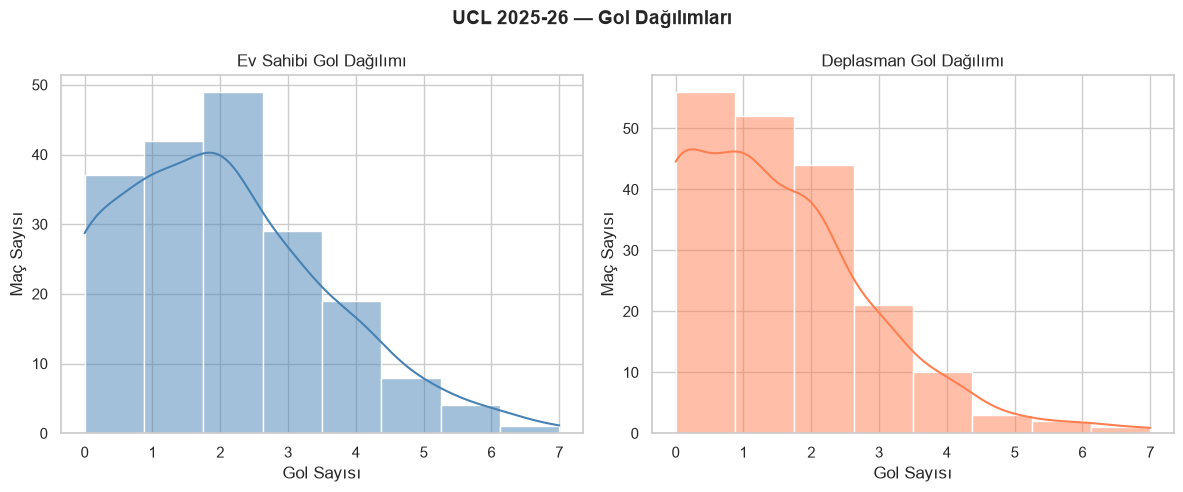

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['FTHG'], kde=True, ax=axes[0], color='steelblue', bins=8)
axes[0].set_title('Ev Sahibi Gol Dağılımı')
axes[0].set_xlabel('Gol Sayısı')
axes[0].set_ylabel('Maç Sayısı')

sns.histplot(df['FTAG'], kde=True, ax=axes[1], color='coral', bins=8)
axes[1].set_title('Deplasman Gol Dağılımı')
axes[1].set_xlabel('Gol Sayısı')
axes[1].set_ylabel('Maç Sayısı')

plt.suptitle('UCL 2025-26 — Gol Dağılımları', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/gol_dagilimi.png', dpi=150)
plt.show()

## Görsel 1: Gol Dağılımı Histogramı

Ev sahibi takımlar en sık 2 gol atarken deplasman takımları
en sık 0-1 gol atmaktadır. Ev sahiplerinin gol dağılımı sağa
daha yayılmış olup daha yüksek gol sayılarına ulaşabildiklerini
göstermektedir. Bu durum ev sahibi avantajının ilk görsel kanıtıdır.

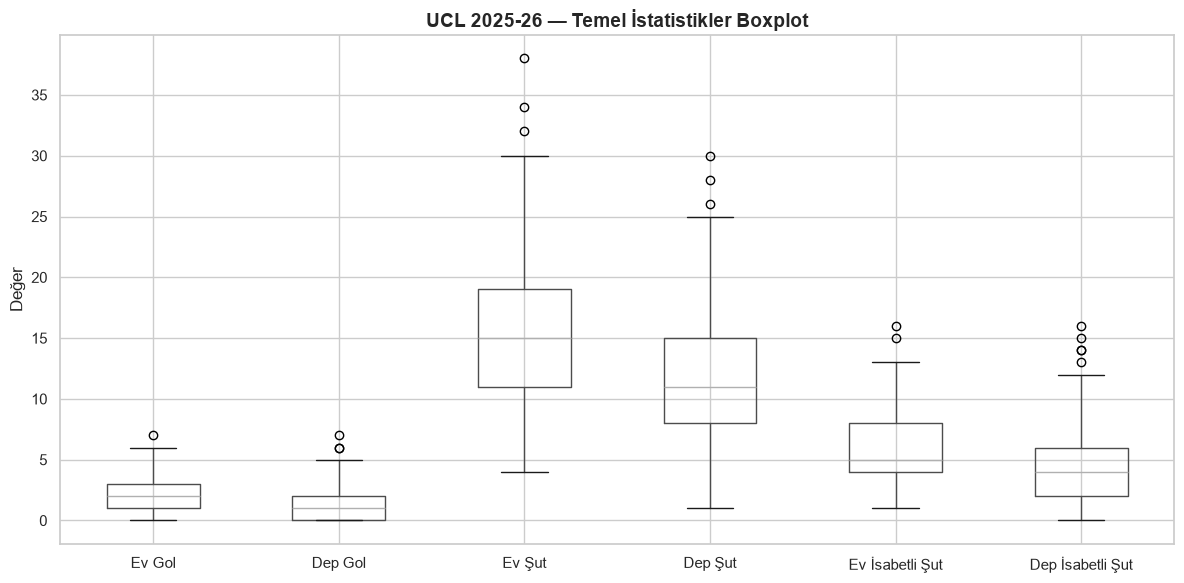

In [77]:
fig, ax = plt.subplots(figsize=(12, 6))

df[['FTHG', 'FTAG', 'HTSFT', 'ATSFT', 'HSONFT', 'ASONFT']].boxplot(ax=ax)

ax.set_xticklabels(['Ev Gol', 'Dep Gol', 'Ev Şut', 'Dep Şut', 
                    'Ev İsabetli Şut', 'Dep İsabetli Şut'])
ax.set_title('UCL 2025-26 — Temel İstatistikler Boxplot', fontsize=14, fontweight='bold')
ax.set_ylabel('Değer')
plt.tight_layout()
plt.savefig('../data/boxplot.png', dpi=150)
plt.show()

## Görsel 2: Boxplot — Aykırı Değer Analizi

Boxplot analizi ev sahibi takımların tüm kategorilerde
(gol, şut, isabetli şut) deplasман takımlarına göre daha
yüksek değerlere sahip olduğunu göstermektedir. Ev şutlarında
34-38 şut olan maçlar aykırı değer olarak tespit edilmiştir.
Bu maçlar tek taraflı geçen karşılaşmalara işaret etmektedir.

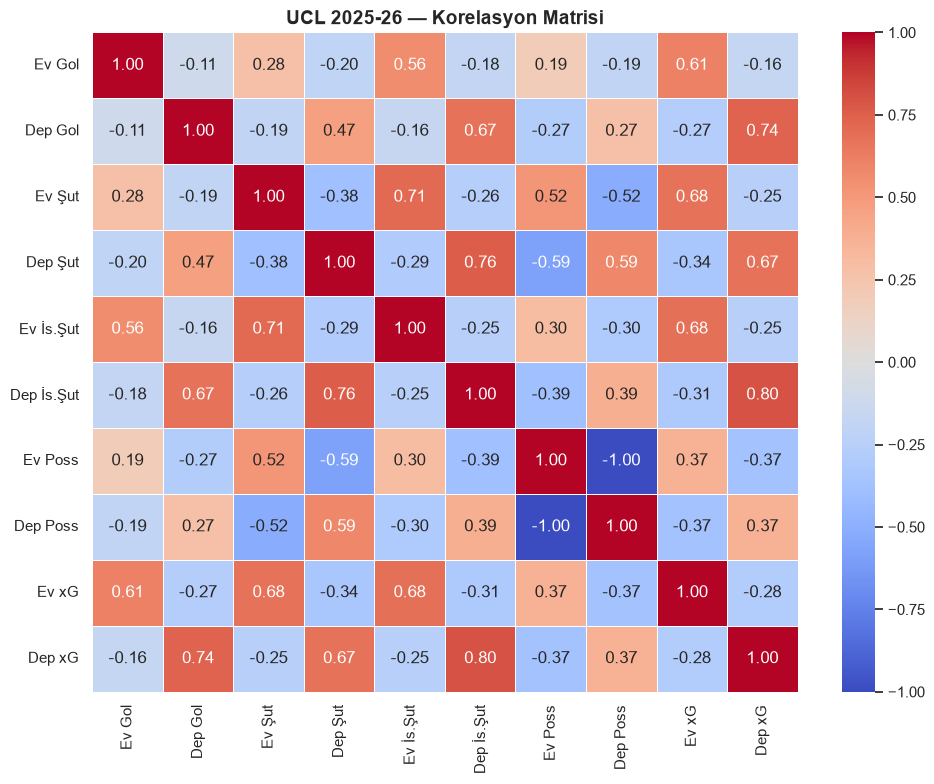

In [78]:
fig, ax = plt.subplots(figsize=(10, 8))

kolonlar = ['FTHG', 'FTAG', 'HTSFT', 'ATSFT', 
            'HSONFT', 'ASONFT', 'HBPFT', 'ABPFT',
            'homeXGFT', 'awayXGFT']

corr = df[kolonlar].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            xticklabels=['Ev Gol', 'Dep Gol', 'Ev Şut', 'Dep Şut',
                         'Ev İs.Şut', 'Dep İs.Şut', 'Ev Poss', 'Dep Poss',
                         'Ev xG', 'Dep xG'],
            yticklabels=['Ev Gol', 'Dep Gol', 'Ev Şut', 'Dep Şut',
                         'Ev İs.Şut', 'Dep İs.Şut', 'Ev Poss', 'Dep Poss',
                         'Ev xG', 'Dep xG'])

ax.set_title('UCL 2025-26 — Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/heatmap.png', dpi=150)
plt.show()

## Görsel 3: Korelasyon Heatmap

En güçlü pozitif ilişkiler: Deplasman isabetli şutu ile deplasman 
golü arasında 0.80, deplasman xG ile deplasman golü arasında 0.74 
korelasyon tespit edilmiştir. Ev sahibi xG ile ev sahibi golü 
arasındaki 0.61 korelasyon, xG'nin gol tahmininde güçlü bir 
gösterge olduğunu doğrulamaktadır.

En güçlü negatif ilişkiler: Ev sahibi ve deplasman top hakimiyeti 
arasında -1.00 korelasyon bulunmaktadır; bu tamamen beklenen bir 
sonuçtur çünkü topun bir takımda olması diğer takımın topu 
elinde bulunduramaması anlamına gelir. Bunun yanında ev sahibi 
top hakimiyeti ile deplasman şutu arasında -0.59 korelasyon 
gözlemlenmiştir; ev sahibi topu ne kadar çok elinde tutarsa 
deplasman o kadar az şut kullanabilmektedir.

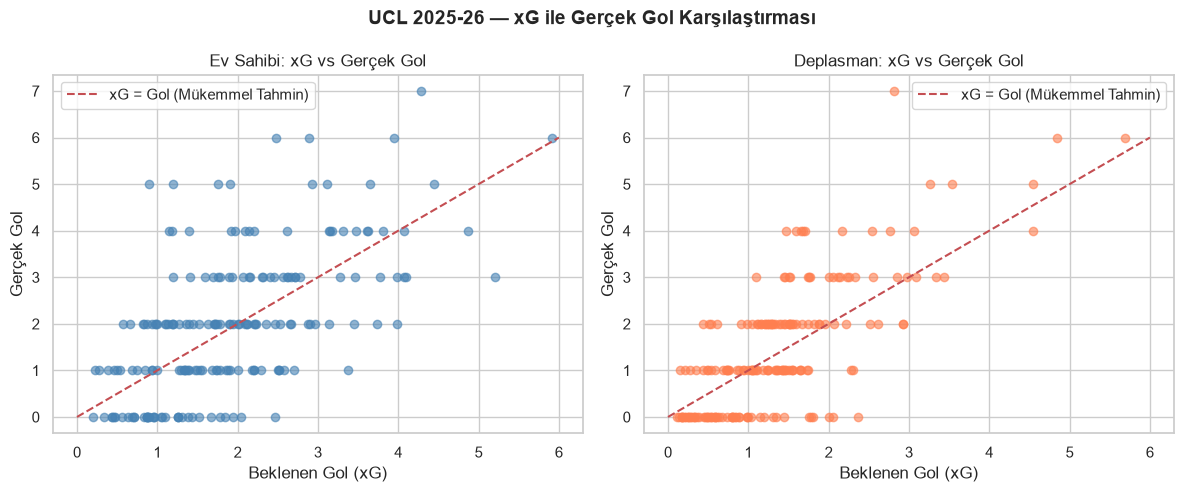

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['homeXGFT'], df['FTHG'], alpha=0.6, color='steelblue')
axes[0].plot([0, 6], [0, 6], 'r--', label='xG = Gol (Mükemmel Tahmin)')
axes[0].set_xlabel('Beklenen Gol (xG)')
axes[0].set_ylabel('Gerçek Gol')
axes[0].set_title('Ev Sahibi: xG vs Gerçek Gol')
axes[0].legend()

axes[1].scatter(df['awayXGFT'], df['FTAG'], alpha=0.6, color='coral')
axes[1].plot([0, 6], [0, 6], 'r--', label='xG = Gol (Mükemmel Tahmin)')
axes[1].set_xlabel('Beklenen Gol (xG)')
axes[1].set_ylabel('Gerçek Gol')
axes[1].set_title('Deplasman: xG vs Gerçek Gol')
axes[1].legend()

plt.suptitle('UCL 2025-26 — xG ile Gerçek Gol Karşılaştırması', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/xg_scatter.png', dpi=150)
plt.show()

## Görsel 4: Scatter Plot — xG vs Gerçek Gol

Ev sahibi takımların xG ile gerçek gol ilişkisi dengeli bir 
dağılım gösterirken deplasman takımlarının noktaları mükemmel 
tahmin çizgisinin altında daha yoğun görünmektedir. Bu durum 
deplasman takımlarının yarattıkları fırsatları ev sahiplerine 
kıyasla daha az değerlendirebildiğine işaret etmektedir.

## Araştırma Soruları

1. Takımları şanslılıklarına göre sırala — xG ile gerçek gol farkı 
   en yüksek ve en düşük takımlar hangileri?
2. Hangi hakem daha güzel futbol oylatıyor? Hakem bazında ortalama 
   gol, şut ve sarı kart analizi
3. UCL 2025-26'da ikinci yarıda mı daha fazla gol atıldı? 
   İkinci yarı hakimiyeti gerçek mi?
4. İlk yarıda öne geçen takımların maç sonu galibiyet oranı nedir?

In [80]:
# Her takım için toplam gol ve xG hesapla
ev = df.groupby('homeTeam').agg(
    gol=('FTHG', 'sum'),
    xg=('homeXGFT', 'sum'),
    mac=('FTHG', 'count')
).reset_index().rename(columns={'homeTeam': 'takim'})

dep = df.groupby('awayTeam').agg(
    gol=('FTAG', 'sum'),
    xg=('awayXGFT', 'sum'),
    mac=('FTAG', 'count')
).reset_index().rename(columns={'awayTeam': 'takim'})

# Ev + deplasman birleştir
takim_stats = pd.concat([ev, dep]).groupby('takim').sum().reset_index()
takim_stats['xg_fark'] = takim_stats['gol'] - takim_stats['xg']
takim_stats = takim_stats.sort_values('xg_fark', ascending=False)

print("EN ŞANSLI 5 TAKIM:")
print(takim_stats.head(5)[['takim', 'gol', 'xg', 'xg_fark']].to_string(index=False))
print("\nEN ŞANSSIZ 5 TAKIM:")
print(takim_stats.tail(5)[['takim', 'gol', 'xg', 'xg_fark']].to_string(index=False))

EN ŞANSLI 5 TAKIM:
        takim  gol    xg  xg_fark
          PSG   45 33.12    11.88
    Barcelona   32 23.19     8.81
  Atl. Madrid   35 28.84     6.16
     Dortmund   22 16.30     5.70
Bayern Munich   43 37.91     5.09

EN ŞANSSIZ 5 TAKIM:
        takim  gol    xg  xg_fark
       Monaco   12 16.55    -4.55
Slavia Prague    5  9.71    -4.71
   Villarreal    5  9.72    -4.72
     Atalanta   16 21.27    -5.27
    Liverpool   24 30.00    -6.00


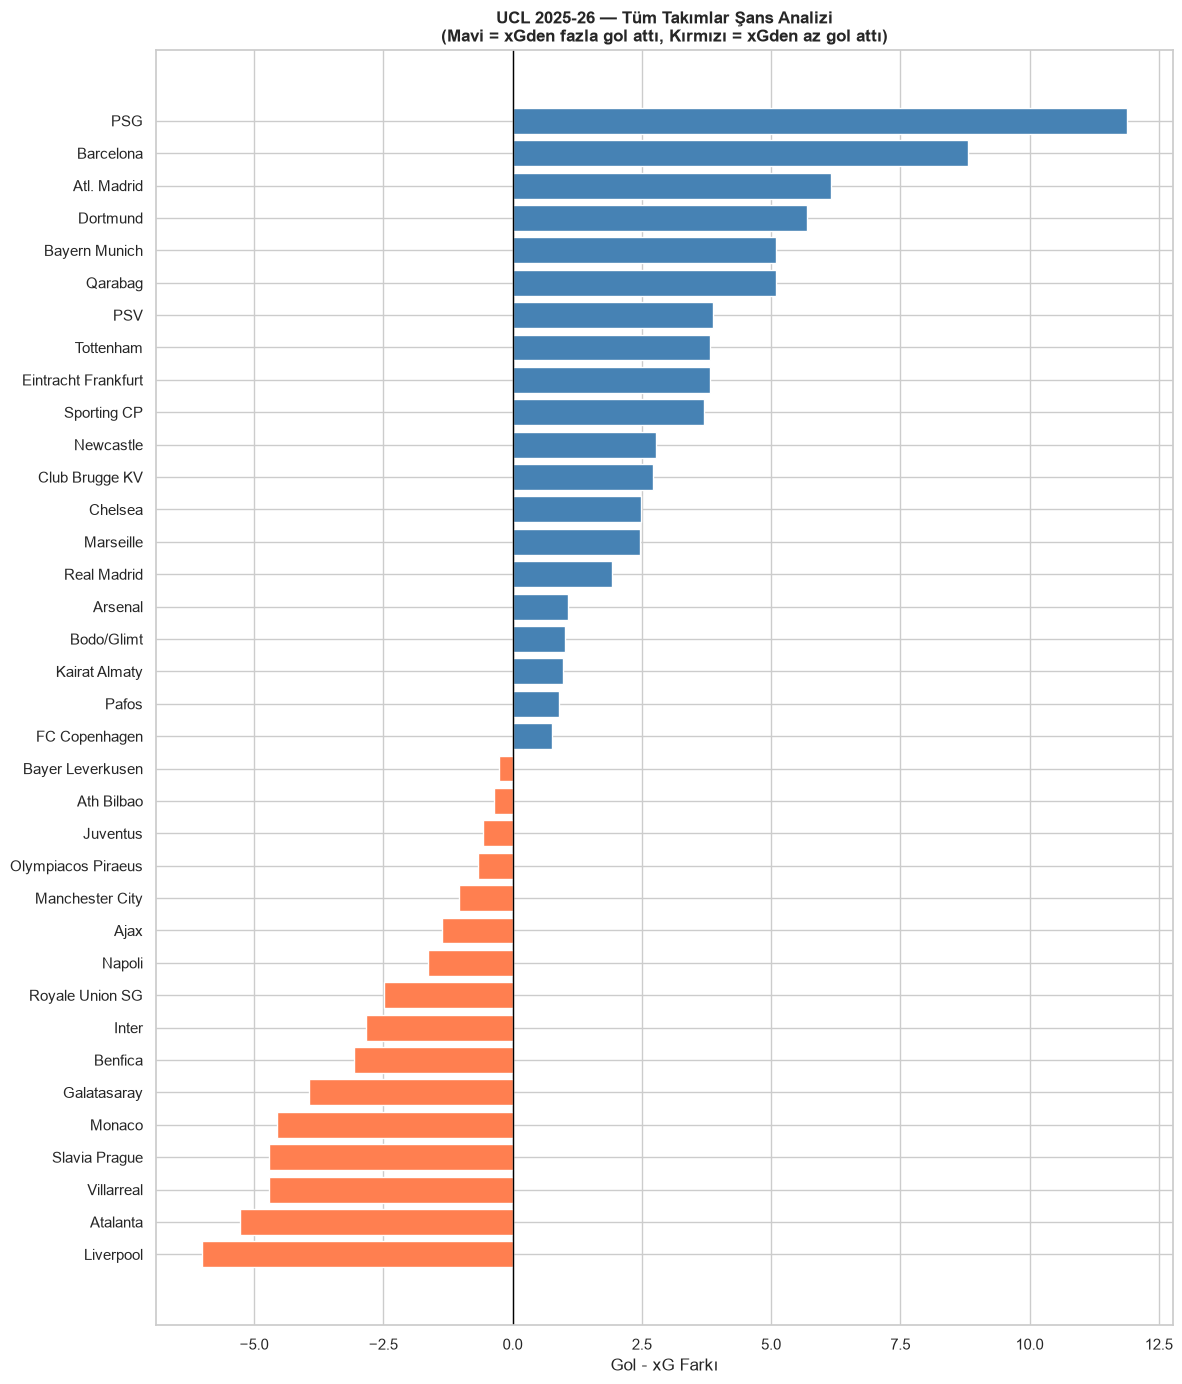

In [81]:
fig, ax = plt.subplots(figsize=(12, 14))

plot_df = takim_stats.sort_values('xg_fark')
renkler = ['coral' if x < 0 else 'steelblue' for x in plot_df['xg_fark']]

ax.barh(plot_df['takim'], plot_df['xg_fark'], color=renkler)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Gol - xG Farkı')
ax.set_title('UCL 2025-26 — Tüm Takımlar Şans Analizi\n(Mavi = xGden fazla gol attı, Kırmızı = xGden az gol attı)', 
             fontweight='bold')
plt.tight_layout()
plt.savefig('../data/sans_analizi.png', dpi=150)
plt.show()

## Araştırma Sorusu 1 Sonucu: xG Şans Analizi

PSG bu sezon xG'sinden 11.88 fazla gol atarak en şanslı/etkili 
takım olmuştur. Barcelona 8.81 farkla ikinci sıradadır. Bu bulgu 
PSG'nin şampiyonluğuyla örtüşmektedir — olağanüstü bitiriş kalitesi 
ve yarattığı fırsatları değerlendirme gücü şampiyonluğun tesadüf 
olmadığını göstermektedir. Buna karşın Liverpool xG'sinden 6 gol 
az atarak en şanssız takım konumundadır. Yarattığı pozisyonları 
yeterince değerlendiremeyen Liverpool'un elenmesi de bu veriyle 
örtüşmektedir. Galatasaray da xG'sinin altında kalarak fırsatlarını 
yeterince değerleyememiştir.

In [82]:
hakem_stats = df.groupby('referee').agg(
    mac_sayisi=('FTHG', 'count'),
    ort_toplam_gol=('FTHG', lambda x: (x + df.loc[x.index, 'FTAG']).mean()),
    ort_ev_sut=('HTSFT', 'mean'),
    ort_dep_sut=('ATSFT', 'mean'),
    ort_sari_kart=('HYCFT', lambda x: (x + df.loc[x.index, 'AYCFT']).mean())
).round(2).reset_index()

# En az 3 maç yönetmiş hakemleri al
hakem_stats = hakem_stats[hakem_stats['mac_sayisi'] >= 3]
hakem_stats = hakem_stats.sort_values('ort_toplam_gol', ascending=False)

print(hakem_stats.to_string(index=False))

                      referee  mac_sayisi  ort_toplam_gol  ort_ev_sut  ort_dep_sut  ort_sari_kart
                 Urs Schnyder           3            5.33       18.67         7.33           4.00
               Sandro Schärer           4            5.25       19.75         7.75           2.75
                  Espen Eskas           6            5.17       15.50        14.50           2.67
                 Davide Massa           5            4.40       18.40        11.20           3.40
                 Felix Zwayer           5            4.40       15.60         7.00           3.80
               Anthony Taylor           4            4.25        9.75        20.50           3.50
            François Letexier           8            4.00       13.50        12.25           2.88
                Ivan Kružliak           6            4.00       18.33         9.33           3.67
               Benoît Bastien           4            4.00       19.25        11.50           4.00
          Alejandro 

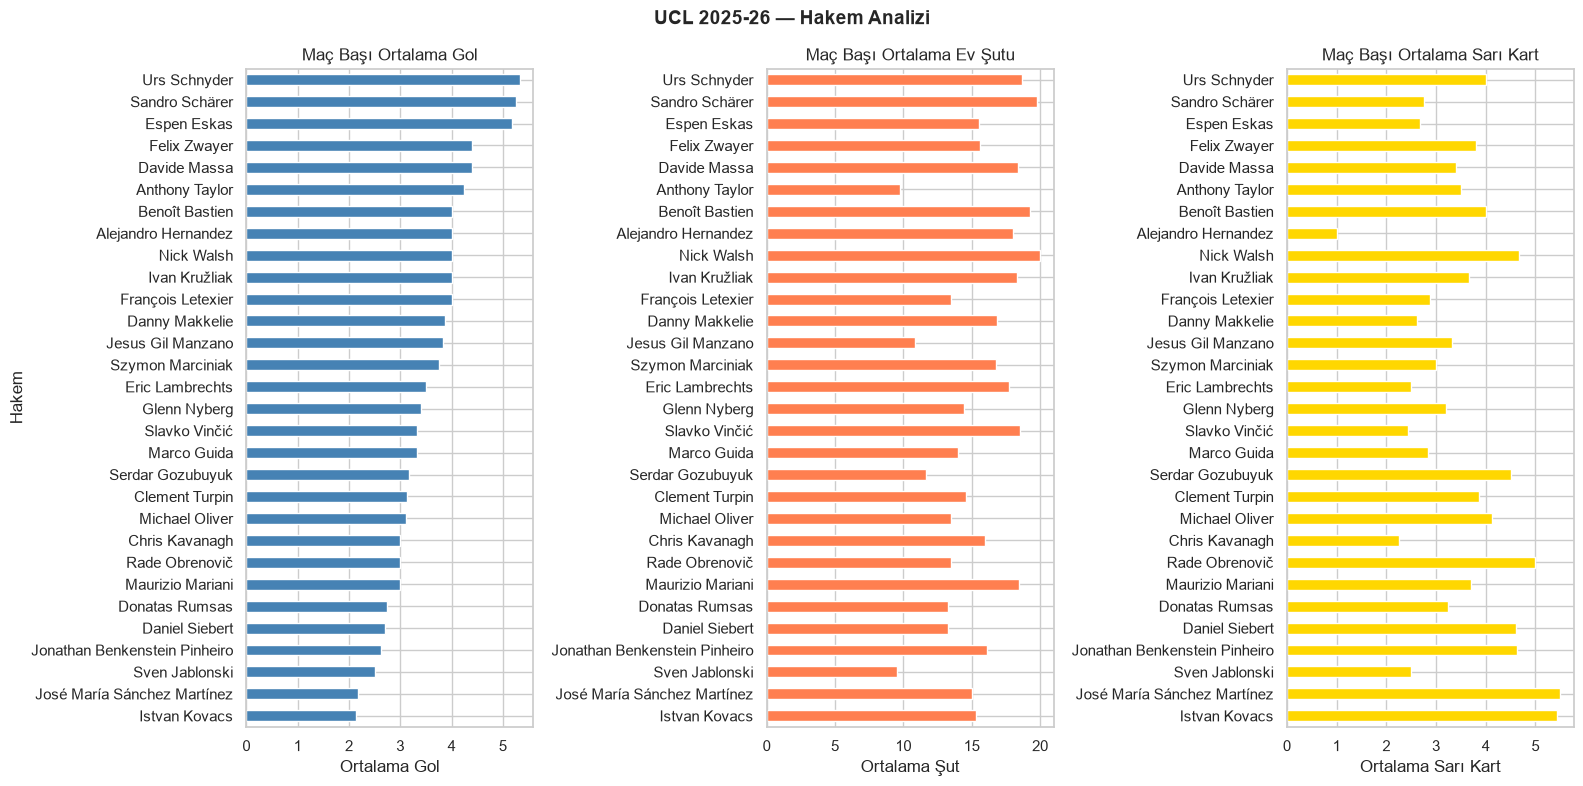

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

# Grafik 1: Ortalama gol
hakem_stats.sort_values('ort_toplam_gol').plot(
    kind='barh', x='referee', y='ort_toplam_gol', 
    ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Maç Başı Ortalama Gol')
axes[0].set_xlabel('Ortalama Gol')
axes[0].set_ylabel('Hakem')

# Grafik 2: Ortalama şut
hakem_stats.sort_values('ort_toplam_gol').plot(
    kind='barh', x='referee', y='ort_ev_sut',
    ax=axes[1], color='coral', legend=False)
axes[1].set_title('Maç Başı Ortalama Ev Şutu')
axes[1].set_xlabel('Ortalama Şut')
axes[1].set_ylabel('')

# Grafik 3: Ortalama sarı kart
hakem_stats.sort_values('ort_toplam_gol').plot(
    kind='barh', x='referee', y='ort_sari_kart',
    ax=axes[2], color='gold', legend=False)
axes[2].set_title('Maç Başı Ortalama Sarı Kart')
axes[2].set_xlabel('Ortalama Sarı Kart')
axes[2].set_ylabel('')

plt.suptitle('UCL 2025-26 — Hakem Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/hakem_analizi.png', dpi=150)
plt.show()

## Araştırma Sorusu 2 Sonucu: Hakem Analizi

En güzel futbolu Espen Eskas yönetmiştir — 6 maçta ortalama 5.17 
gol ve sadece 2.67 sarı kart ile hem gollü hem temiz maçlar 
ortaya çıkmıştır. Buna karşın Istvan Kovacs en sıkıcı hakemdir; 
ortalama 2.14 gol ve 5.43 sarı kart ile hem az gollü hem sert 
geçen maçlar yönetmiştir.

In [84]:
# 1. ve 2. yarı gol toplamları
gol_1H = (df['1HHG'] + df['1HAG']).sum()
gol_2H = (df['2HHG'] + df['2HAG']).sum()

print(f"1. Yarı toplam gol: {gol_1H}")
print(f"2. Yarı toplam gol: {gol_2H}")
print(f"\nMaç başı 1. yarı ortalama: {(df['1HHG'] + df['1HAG']).mean():.2f}")
print(f"Maç başı 2. yarı ortalama: {(df['2HHG'] + df['2HAG']).mean():.2f}")

1. Yarı toplam gol: 284
2. Yarı toplam gol: 367

Maç başı 1. yarı ortalama: 1.50
Maç başı 2. yarı ortalama: 1.94


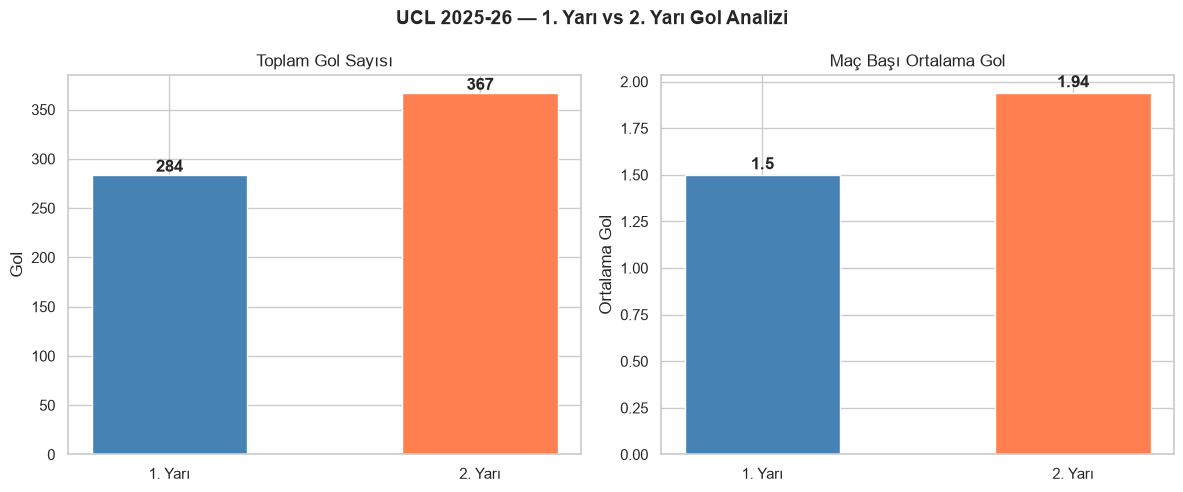

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafik 1: Toplam gol karşılaştırması
yarlar = ['1. Yarı', '2. Yarı']
toplamlar = [gol_1H, gol_2H]
renkler = ['steelblue', 'coral']

axes[0].bar(yarlar, toplamlar, color=renkler, width=0.5)
axes[0].set_title('Toplam Gol Sayısı')
axes[0].set_ylabel('Gol')
for i, v in enumerate(toplamlar):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Grafik 2: Maç başı ortalama
ortalamalar = [1.50, 1.94]
axes[1].bar(yarlar, ortalamalar, color=renkler, width=0.5)
axes[1].set_title('Maç Başı Ortalama Gol')
axes[1].set_ylabel('Ortalama Gol')
for i, v in enumerate(ortalamalar):
    axes[1].text(i, v + 0.03, str(v), ha='center', fontweight='bold')

plt.suptitle('UCL 2025-26 — 1. Yarı vs 2. Yarı Gol Analizi', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/yari_gol_analizi.png', dpi=150)
plt.show()

## Araştırma Sorusu 3 Sonucu: İkinci Yarı Gol Hakimiyeti

UCL 2025-26'da 2. yarıda 367 gol atılırken 1. yarıda 284 gol 
atılmıştır. Bu da 2. yarının %29 daha gollü geçtiğini göstermektedir. 
Maç başı ortalamaya bakıldığında 1. yarıda 1.50, 2. yarıda 1.94 
gol atılmıştır. Bu bulgu futbolda yaygın olan "ikinci yarıda daha 
fazla gol atılır" söylemini veriyle doğrulamaktadır. Kondisyon 
düşüşü, taktik değişiklikler ve geride kalan takımların risk alması 
bu farkın temel nedenleri olarak değerlendirilebilir.

In [86]:
# İlk yarı durumuna göre maçları sınıflandır
def ilk_yari_durum(row):
    if row['1HHG'] > row['1HAG']:
        return 'Ev Önde'
    elif row['1HHG'] < row['1HAG']:
        return 'Dep Önde'
    else:
        return 'Berabere'

df['ilk_yari'] = df.apply(ilk_yari_durum, axis=1)

# Maç sonu sonuçlarıyla karşılaştır
print("=== İLK YARIDA ÖNDE OLAN TAKIMIN MAÇ SONU SONUCU ===\n")

for durum in ['Ev Önde', 'Dep Önde', 'Berabere']:
    alt_df = df[df['ilk_yari'] == durum]
    toplam = len(alt_df)
    print(f"1. Yarı: {durum} ({toplam} maç)")
    print(alt_df['FTR'].value_counts(normalize=True).mul(100).round(1).to_string())
    print()

=== İLK YARIDA ÖNDE OLAN TAKIMIN MAÇ SONU SONUCU ===

1. Yarı: Ev Önde (75 maç)
FTR
H    84.0
D     9.3
A     6.7

1. Yarı: Dep Önde (44 maç)
FTR
A    63.6
D    18.2
H    18.2

1. Yarı: Berabere (70 maç)
FTR
A    40.0
H    32.9
D    27.1



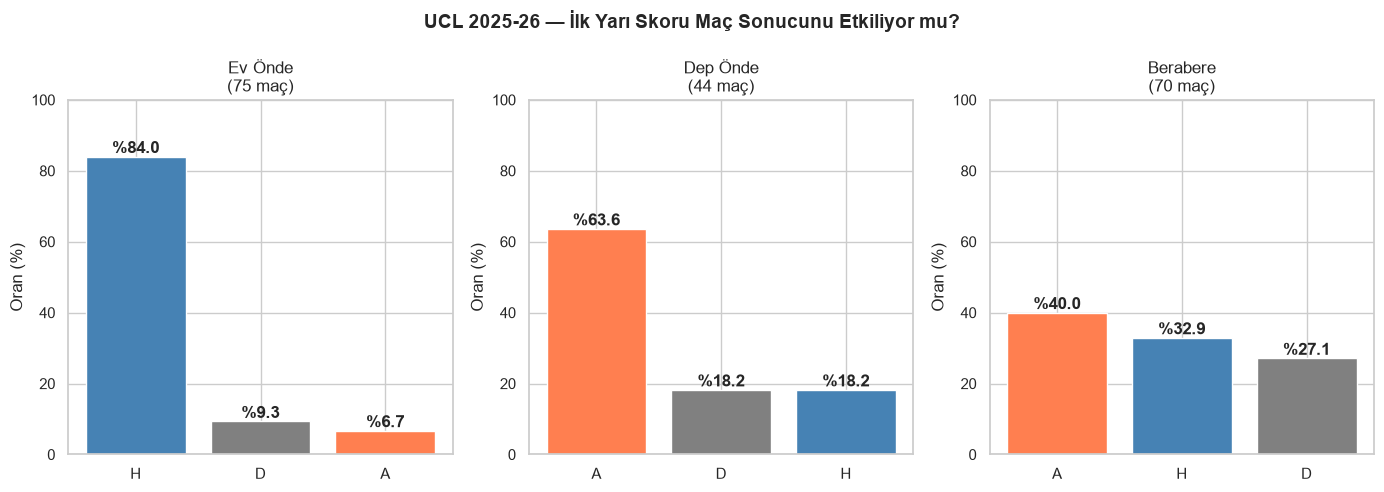

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

durumlar = {
    'Ev Önde\n(75 maç)': df[df['ilk_yari'] == 'Ev Önde']['FTR'].value_counts(normalize=True).mul(100).round(1),
    'Dep Önde\n(44 maç)': df[df['ilk_yari'] == 'Dep Önde']['FTR'].value_counts(normalize=True).mul(100).round(1),
    'Berabere\n(70 maç)': df[df['ilk_yari'] == 'Berabere']['FTR'].value_counts(normalize=True).mul(100).round(1)
}

renkler = {'H': 'steelblue', 'A': 'coral', 'D': 'gray'}

for ax, (baslik, data) in zip(axes, durumlar.items()):
    renkler_list = [renkler.get(x, 'gray') for x in data.index]
    bars = ax.bar(data.index, data.values, color=renkler_list)
    ax.set_title(baslik)
    ax.set_ylabel('Oran (%)')
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'%{val}', ha='center', fontweight='bold')

plt.suptitle('UCL 2025-26 — İlk Yarı Skoru Maç Sonucunu Etkiliyor mu?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/ilk_yari_analizi.png', dpi=150)
plt.show()

## Araştırma Sorusu 4 Sonucu: İlk Yarı Skoru Belirleyici mi?

UCL 2025-26 verileri ilk yarı skorunun maç sonucu üzerinde çok 
güçlü bir etkisi olduğunu ortaya koymaktadır. İlk yarıda öne geçen 
ev sahibi takımlar %84 oranında maçı kazanmıştır — bu son derece 
yüksek bir oran olup ev sahibi avantajıyla birleşince neredeyse 
kesin sonuç anlamına gelmektedir. Deplasmanda öne geçen takımlar 
ise %63.6 oranında maçı kazanmıştır. İlk yarıyı berabere kapatan 
maçlarda ise sonuçlar çok dağınık olup herhangi bir takım için 
belirgin bir avantaj gözlemlenmemiştir. Bu bulgular ilk yarıda 
öne geçmenin UCL'de belirleyici bir faktör olduğunu doğrulamaktadır.

In [88]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Özellikler ve hedef değişken
X = df[['HTSFT', 'HSONFT', 'homeXGFT']]
y = df['FTHG']

# Standart ölçekleme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f"Eğitim seti: {X_train.shape[0]} maç")
print(f"Test seti:   {X_test.shape[0]} maç")

Eğitim seti: 151 maç
Test seti:   38 maç


In [89]:
# Ridge Regresyon + GridSearchCV ile hiperparametre optimizasyonu
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"En iyi alpha: {grid_search.best_params_['alpha']}")
print(f"En iyi CV R² skoru: {grid_search.best_score_:.3f}")

# Test seti tahmini
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nTest Seti Sonuçları:")
print(f"  RMSE: {rmse:.3f} gol")
print(f"  R²:   {r2:.3f}")

En iyi alpha: 1
En iyi CV R² skoru: 0.410

Test Seti Sonuçları:
  RMSE: 1.040 gol
  R²:   0.679


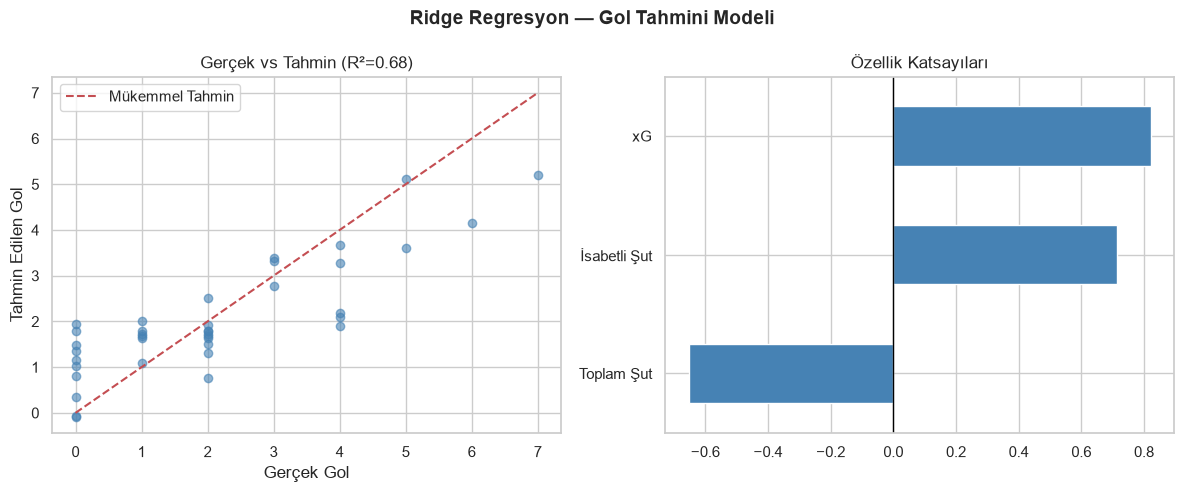

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafik 1: Gerçek vs Tahmin
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')
axes[0].plot([0, 7], [0, 7], 'r--', label='Mükemmel Tahmin')
axes[0].set_xlabel('Gerçek Gol')
axes[0].set_ylabel('Tahmin Edilen Gol')
axes[0].set_title(f'Gerçek vs Tahmin (R²={r2:.2f})')
axes[0].legend()

# Grafik 2: Özellik katsayıları
coefs = pd.Series(best_model.coef_, 
                  index=['Toplam Şut', 'İsabetli Şut', 'xG'])
coefs.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Özellik Katsayıları')
axes[1].axvline(x=0, color='black', linewidth=1)

plt.suptitle('Ridge Regresyon — Gol Tahmini Modeli', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_sonuc.png', dpi=150)
plt.show()

## Modelleme Sonucu: Ridge Regresyon

Ev sahibi takımın gol sayısını tahmin etmek için toplam şut,
isabetli şut ve xG değişkenleri kullanılmıştır. GridSearchCV ile
en iyi alpha değeri 1 olarak belirlenmiştir. Model test setinde
R²=0.679 ve RMSE=1.040 gol performansı göstermiştir. Özellik
katsayıları incelendiğinde xG'nin (0.80) en güçlü tahmin edici
olduğu görülmektedir. İlginç olarak toplam şut sayısı negatif
katsayıya sahipken isabetli şut pozitif katsayıya sahiptir —
bu bulgu şut miktarından çok şut kalitesinin belirleyici
olduğunu ortaya koymaktadır.

## Genel Sonuçlar ve Değerlendirme

UCL 2025-26 verileri üzerinde yapılan analizde şu bulgular
elde edilmiştir:

1. PSG xG'sinden 11.88 fazla gol atarak şampiyonluğunu
   istatistiksel olarak da desteklemiştir.
2. Espen Eskas maç başı 5.17 gol ortalamasıyla en güzel
   futbolu yönetmiştir.
3. İkinci yarıda birinci yarıya göre %29 daha fazla gol
   atılmıştır.
4. İlk yarıda öne geçen ev sahibi takımlar %84 oranında
   maçı kazanmıştır.
5. Ridge Regresyon modeli gol tahmininde R²=0.679 başarı
   elde etmiş, xG en belirleyici değişken olmuştur.